<table>
<tr>
<td>


# TFG - Visualización de Resultados

### Estimación de rendimiento de cultivos utilizando inteligencia artificial y datos de observación de la tierra.

**Nacor Olmos Caballero**

</td>
<td>
<img src="./img/logo_uv.png" width="250" height="250">
</td>
</tr>
</table>

## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

## Datos

In [2]:
maiz = pd.read_csv("./Clean_Data/df_maize_final.csv", index_col=0)
arroz = pd.read_csv("./Clean_Data/df_rice_final.csv", index_col=0)
trigo = pd.read_csv("./Clean_Data/df_wheat_final.csv", index_col=0)

# DataFrames para nombres de columnas
col_names_train_maize = pd.read_csv("./Clean_Data/mod_maiz.csv", index_col=0).columns.tolist()
col_names_train_rice = pd.read_csv("./Clean_Data/mod_arroz.csv", index_col=0).columns.tolist()
col_names_train_wheat = pd.read_csv("./Clean_Data/mod_trigo.csv", index_col=0).columns.tolist()

### Resultados de K-Fold

In [3]:
kfold_maiz_rf1 = pd.read_csv("./Resultados/resultados_kfold_maiz_rf1.csv", index_col=0)
kfold_maiz_rf2 = pd.read_csv("./Resultados/resultados_kfold_maiz_rf2.csv", index_col=0)
kfold_maiz_rf3 = pd.read_csv("./Resultados/resultados_kfold_maiz_rf3.csv", index_col=0)
kfold_maiz_xgb1 = pd.read_csv("./Resultados/resultados_kfold_maiz_xgb1.csv", index_col=0)
kfold_maiz_xgb2 = pd.read_csv("./Resultados/resultados_kfold_maiz_xgb2.csv", index_col=0)
kfold_maiz_xgb3 = pd.read_csv("./Resultados/resultados_kfold_maiz_xgb3.csv", index_col=0)
kfold_maiz_lgb1 = pd.read_csv("./Resultados/resultados_kfold_maiz_lgb1.csv", index_col=0)
kfold_maiz_lgb2 = pd.read_csv("./Resultados/resultados_kfold_maiz_lgb2.csv", index_col=0)
kfold_maiz_lgb3 = pd.read_csv("./Resultados/resultados_kfold_maiz_lgb3.csv", index_col=0)
kfold_maiz_svr1 = pd.read_csv("./Resultados/resultados_kfold_maiz_svr1.csv", index_col=0)
kfold_maiz_svr2 = pd.read_csv("./Resultados/resultados_kfold_maiz_svr2.csv", index_col=0)
kfold_maiz_svr3 = pd.read_csv("./Resultados/resultados_kfold_maiz_svr3.csv", index_col=0)

kfold_arroz_rf1 = pd.read_csv("./Resultados/resultados_kfold_arroz_rf1.csv", index_col=0)
kfold_arroz_rf2 = pd.read_csv("./Resultados/resultados_kfold_arroz_rf2.csv", index_col=0)
kfold_arroz_rf3 = pd.read_csv("./Resultados/resultados_kfold_arroz_rf3.csv", index_col=0)
kfold_arroz_xgb1 = pd.read_csv("./Resultados/resultados_kfold_arroz_xgb1.csv", index_col=0)
kfold_arroz_xgb2 = pd.read_csv("./Resultados/resultados_kfold_arroz_xgb2.csv", index_col=0)
kfold_arroz_xgb3 = pd.read_csv("./Resultados/resultados_kfold_arroz_xgb3.csv", index_col=0)
kfold_arroz_lgb1 = pd.read_csv("./Resultados/resultados_kfold_arroz_lgb1.csv", index_col=0)
kfold_arroz_lgb2 = pd.read_csv("./Resultados/resultados_kfold_arroz_lgb2.csv", index_col=0)
kfold_arroz_lgb3 = pd.read_csv("./Resultados/resultados_kfold_arroz_lgb3.csv", index_col=0)
kfold_arroz_svr1 = pd.read_csv("./Resultados/resultados_kfold_arroz_svr1.csv", index_col=0)
kfold_arroz_svr2 = pd.read_csv("./Resultados/resultados_kfold_arroz_svr2.csv", index_col=0)
kfold_arroz_svr3 = pd.read_csv("./Resultados/resultados_kfold_arroz_svr3.csv", index_col=0)

kfold_trigo_rf1 = pd.read_csv("./Resultados/resultados_kfold_trigo_rf1.csv", index_col=0)
kfold_trigo_rf2 = pd.read_csv("./Resultados/resultados_kfold_trigo_rf2.csv", index_col=0)
kfold_trigo_rf3 = pd.read_csv("./Resultados/resultados_kfold_trigo_rf3.csv", index_col=0)
kfold_trigo_xgb1 = pd.read_csv("./Resultados/resultados_kfold_trigo_xgb1.csv", index_col=0)
kfold_trigo_xgb2 = pd.read_csv("./Resultados/resultados_kfold_trigo_xgb2.csv", index_col=0)
kfold_trigo_xgb3 = pd.read_csv("./Resultados/resultados_kfold_trigo_xgb3.csv", index_col=0)
kfold_trigo_lgb1 = pd.read_csv("./Resultados/resultados_kfold_trigo_lgb1.csv", index_col=0)
kfold_trigo_lgb2 = pd.read_csv("./Resultados/resultados_kfold_trigo_lgb2.csv", index_col=0)
kfold_trigo_lgb3 = pd.read_csv("./Resultados/resultados_kfold_trigo_lgb3.csv", index_col=0)
kfold_trigo_svr1 = pd.read_csv("./Resultados/resultados_kfold_trigo_svr1.csv", index_col=0)
kfold_trigo_svr2 = pd.read_csv("./Resultados/resultados_kfold_trigo_svr2.csv", index_col=0)
kfold_trigo_svr3 = pd.read_csv("./Resultados/resultados_kfold_trigo_svr3.csv", index_col=0)

### Resultados de Ventana Temporal

In [4]:
vent_maiz_rf1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_rf1.csv", index_col=0)
vent_maiz_rf2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_rf2.csv", index_col=0)
vent_maiz_rf3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_rf3.csv", index_col=0)
vent_maiz_xgb1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_xgb1.csv", index_col=0)
vent_maiz_xgb2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_xgb2.csv", index_col=0)
vent_maiz_xgb3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_xgb3.csv", index_col=0)
vent_maiz_lgb1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_lgb1.csv", index_col=0)
vent_maiz_lgb2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_lgb2.csv", index_col=0)
vent_maiz_lgb3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_lgb3.csv", index_col=0)
vent_maiz_svr1 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_svr1.csv", index_col=0)
vent_maiz_svr2 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_svr2.csv", index_col=0)
vent_maiz_svr3 = pd.read_csv("./Resultados/resultados_vent_temp_maiz_svr3.csv", index_col=0)

vent_arroz_rf1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_rf1.csv", index_col=0)
vent_arroz_rf2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_rf2.csv", index_col=0)
vent_arroz_rf3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_rf3.csv", index_col=0)
vent_arroz_xgb1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_xgb1.csv", index_col=0)
vent_arroz_xgb2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_xgb2.csv", index_col=0)
vent_arroz_xgb3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_xgb3.csv", index_col=0)
vent_arroz_lgb1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_lgb1.csv", index_col=0)
vent_arroz_lgb2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_lgb2.csv", index_col=0)
vent_arroz_lgb3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_lgb3.csv", index_col=0)
vent_arroz_svr1 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_svr1.csv", index_col=0)
vent_arroz_svr2 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_svr2.csv", index_col=0)
vent_arroz_svr3 = pd.read_csv("./Resultados/resultados_vent_temp_arroz_svr3.csv", index_col=0)

vent_trigo_rf1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_rf1.csv", index_col=0)
vent_trigo_rf2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_rf2.csv", index_col=0)
vent_trigo_rf3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_rf3.csv", index_col=0)
vent_trigo_xgb1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_xgb1.csv", index_col=0)
vent_trigo_xgb2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_xgb2.csv", index_col=0)
vent_trigo_xgb3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_xgb3.csv", index_col=0)
vent_trigo_lgb1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_lgb1.csv", index_col=0)
vent_trigo_lgb2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_lgb2.csv", index_col=0)
vent_trigo_lgb3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_lgb3.csv", index_col=0)
vent_trigo_svr1 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_svr1.csv", index_col=0)
vent_trigo_svr2 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_svr2.csv", index_col=0)
vent_trigo_svr3 = pd.read_csv("./Resultados/resultados_vent_temp_trigo_svr3.csv", index_col=0)

In [5]:
rutas_modelos_kfold = {
    "Random Forest": [kfold_maiz_rf1, kfold_maiz_rf2, kfold_maiz_rf3,
                      kfold_arroz_rf1, kfold_arroz_rf2, kfold_arroz_rf3,
                     kfold_trigo_rf1, kfold_trigo_rf2, kfold_trigo_rf3],
    "XGBoost": [kfold_maiz_xgb1, kfold_maiz_xgb2, kfold_maiz_xgb3,
                kfold_arroz_xgb1, kfold_arroz_xgb2, kfold_arroz_xgb3,
                kfold_trigo_xgb1, kfold_trigo_xgb2, kfold_trigo_xgb3],
    "LightGBM": [kfold_maiz_lgb1, kfold_maiz_lgb2, kfold_maiz_lgb3,
                 kfold_arroz_lgb1, kfold_arroz_lgb2, kfold_arroz_lgb3,
                 kfold_trigo_lgb1, kfold_trigo_lgb2, kfold_trigo_lgb3],
    "SVR": [kfold_maiz_svr1, kfold_maiz_svr2, kfold_maiz_svr3,
            kfold_arroz_svr1, kfold_arroz_svr2, kfold_arroz_svr3,
            kfold_trigo_svr1, kfold_trigo_svr2, kfold_trigo_svr3]
}

rutas_modelos_vent = {
    "Random Forest": [vent_maiz_rf1, vent_maiz_rf2, vent_maiz_rf3,
                      vent_arroz_rf1, vent_arroz_rf2, vent_arroz_rf3,
                      vent_trigo_rf1, vent_trigo_rf2, vent_trigo_rf3],
    "XGBoost": [vent_maiz_xgb1, vent_maiz_xgb2, vent_maiz_xgb3,
                vent_arroz_xgb1, vent_arroz_xgb2, vent_arroz_xgb3,
                vent_trigo_xgb1, vent_trigo_xgb2, vent_trigo_xgb3],
    "LightGBM": [vent_maiz_lgb1, vent_maiz_lgb2, vent_maiz_lgb3,
                 vent_arroz_lgb1, vent_arroz_lgb2, vent_arroz_lgb3,
                 vent_trigo_lgb1, vent_trigo_lgb2, vent_trigo_lgb3],
    "SVR": [vent_maiz_svr1, vent_maiz_svr2, vent_maiz_svr3,
            vent_arroz_svr1, vent_arroz_svr2, vent_arroz_svr3,
            vent_trigo_svr1, vent_trigo_svr2, vent_trigo_svr3]
}

## Visualización

### Comparación de resultados por tipo de modelo, estrategia y metodología

#### Preparación de datos

Vamos a realizar una primera visualización general uniendo los resultados de todos los modelos, así como de las dos estrategias de entrenamiento planteadas y las tres metodologías de agrupamiento aplicadas para cada uno. Emplearemos como métricas el valor medio del rRMSE y rME (rRMSE Global y rME Global, respectivamente).

In [6]:
def unir_resultados(rutas_modelos):
    res = [] 

    for modelo, resultados in rutas_modelos.items():

        for i, df in enumerate(resultados):
            df_aux = df.copy()

            if i < 3:
                cultivo = "Maíz"
            elif i < 6:
                cultivo = "Arroz"
            else:
                cultivo = "Trigo"

            if i in [0, 3, 6]:
                met = 1
            elif i in [1, 4, 7]:
                met = 2
            else:
                met = 3

            res_parciales = {
                "Modelo": modelo,
                "Metodología": met,
                "Cultivo": cultivo,
                "rRMSE Global": df_aux["rRMSE"].mean(),
                "ME Global": df_aux["nME"].mean()
            }

            res.append(res_parciales)
    
    return pd.DataFrame(res)

In [7]:
df_kfold_total = unir_resultados(rutas_modelos_kfold)
df_vent_total = unir_resultados(rutas_modelos_vent)

df_kfold_total["Estrategia"] = "KFold"
df_vent_total["Estrategia"] = "Ventana"

In [8]:
df_total = pd.merge(df_kfold_total, df_vent_total, on=["Modelo", "Metodología", "Cultivo", "Estrategia"], how="outer")

In [9]:
# Combinamos columnas de rRMSE y ME usando combine_first (prioriza KFold y luego Ventana)
df_total["rRMSE"] = df_total["rRMSE Global_x"].combine_first(df_total["rRMSE Global_y"])
df_total["ME"] = df_total["ME Global_x"].combine_first(df_total["ME Global_y"])

# Eliminamos las columnas auxiliares
df_total = df_total.drop(columns=["rRMSE Global_x", "rRMSE Global_y", "ME Global_x", "ME Global_y"])

# Mostramos resultado
df_total.head(10)


,Modelo,Metodología,Cultivo,Estrategia,rRMSE,ME
0,LightGBM,1,Arroz,KFold,8.520371,-0.001882
1,LightGBM,1,Arroz,Ventana,9.603296,0.015390
2,LightGBM,1,Maíz,KFold,19.381190,-0.029543
3,LightGBM,1,Maíz,Ventana,20.171079,-0.011170
4,LightGBM,1,Trigo,KFold,16.211021,-0.024353
5,LightGBM,1,Trigo,Ventana,18.129977,0.028979
6,LightGBM,2,Arroz,KFold,12.933765,-0.002330
7,LightGBM,2,Arroz,Ventana,15.929492,0.004462
8,LightGBM,2,Maíz,KFold,21.409919,-0.027162
9,LightGBM,2,Maíz,Ventana,23.373837,0.028917


#### Gráficos de barras globales

In [10]:
def barplot_global(df_orig):
    """Mostrar un barplot global de rRMSE y ME por modelo.
    
    Args:
        df (DataFrame): DataFrame con los resultados globales por modelo.
    """
    # Agrupamos por modelo para calcular media y desviación estándar
    df = df_orig.copy()
    df = df.groupby(["Modelo"])[["rRMSE", "ME"]].mean().reset_index()
    
    fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

    # Paleta de colores
    modelos = df["Modelo"].unique().tolist()
    colores = sns.color_palette("husl", len(modelos))
    paleta = dict(zip(modelos, colores))

    # Barplot de rRMSE
    sns.barplot(data=df.sort_values(by="rRMSE", ascending=True), x="Modelo", y="rRMSE",
                ax=ax[0], label="rRMSE", palette=paleta)
    ax[0].set_title("rRMSE promedio por Modelo")
    ax[0].set_ylabel("rRMSE (%)")
    ax[0].set_xticklabels(ax[0].get_xticklabels())

    # Barplot de ME 
    sns.barplot(data=df.sort_values(by="ME", ascending=True), x="Modelo", y="ME",
                ax=ax[1], label="ME", palette=paleta)
    ax[1].set_title("ME promedio por Modelo")
    ax[1].set_ylabel("ME")
    ax[1].set_xticklabels(ax[1].get_xticklabels())

    plt.suptitle("Comparación global por Modelo", fontsize=16)
    plt.tight_layout()
    plt.show()

In [11]:
def barplot_comparativo(df_orig):
    """Mostrar un barplot comparativo de rRMSE y ME por cultivo y metodología.
    
    Args:
        df_orig (DataFrame): DataFrame con los resultados por cultivo y metodología.
    """
    df = df_orig.copy()

    # rRMSE
    sns.catplot(data=df, x="Modelo", y="rRMSE", hue="Metodología",
                col="Cultivo", kind="bar", palette="Set2",
                ci="sd", height=5, aspect=1.5).set_titles("{col_name}")

    # ME
    sns.catplot(data=df, x="Modelo", y="ME", hue="Metodología",
                col="Cultivo", kind="bar", palette="Set2",
                ci="sd", height=5, aspect=1.5).set_titles("{col_name}")

    plt.tight_layout()
    plt.show()

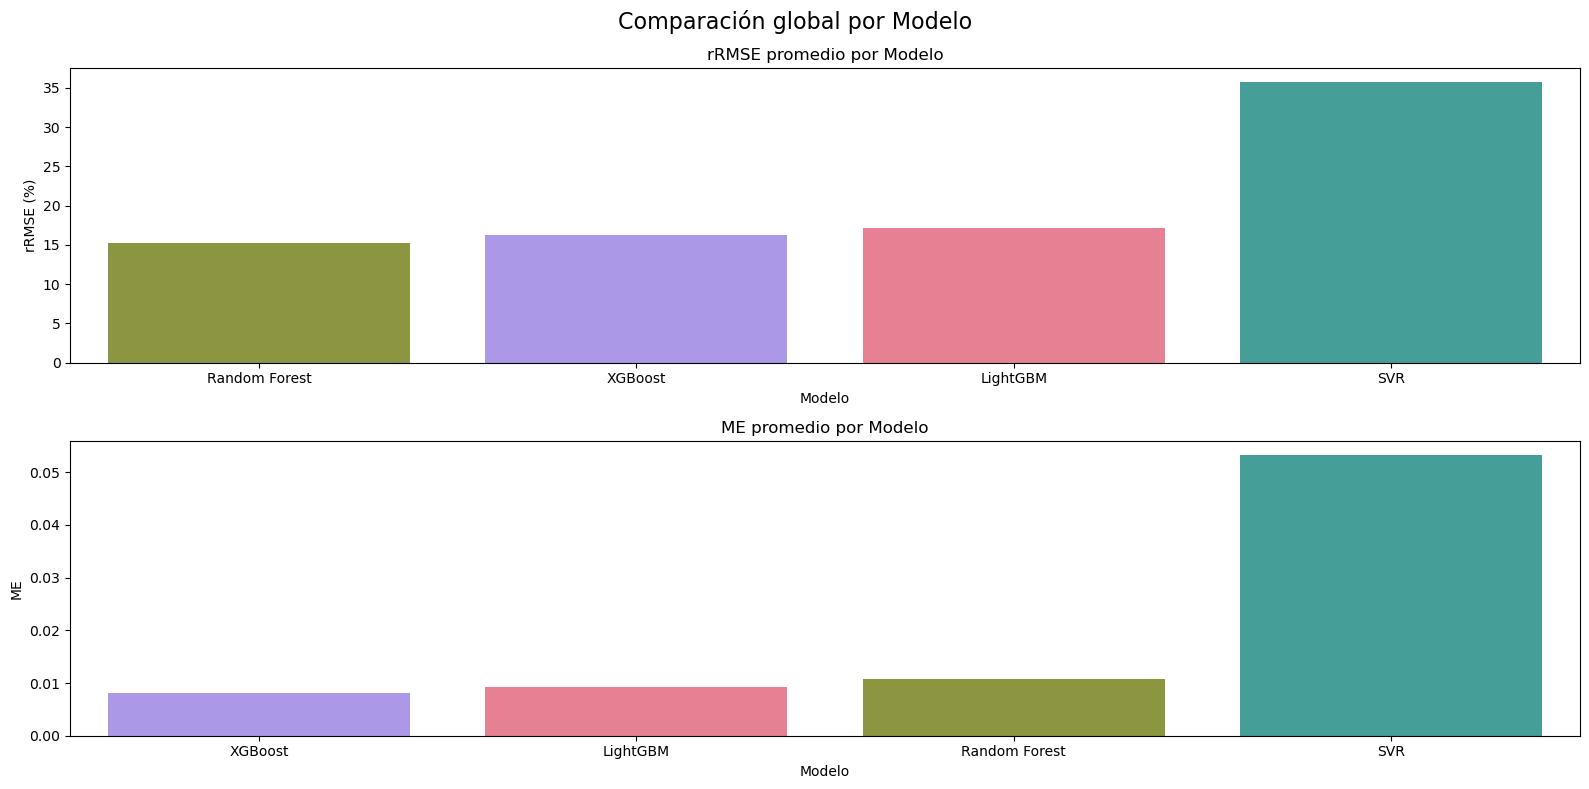

In [12]:
barplot_global(df_total)

De manera general, podemos deicr que los modelos SVR son los que peor funcionan para nuestro caso de estudio.

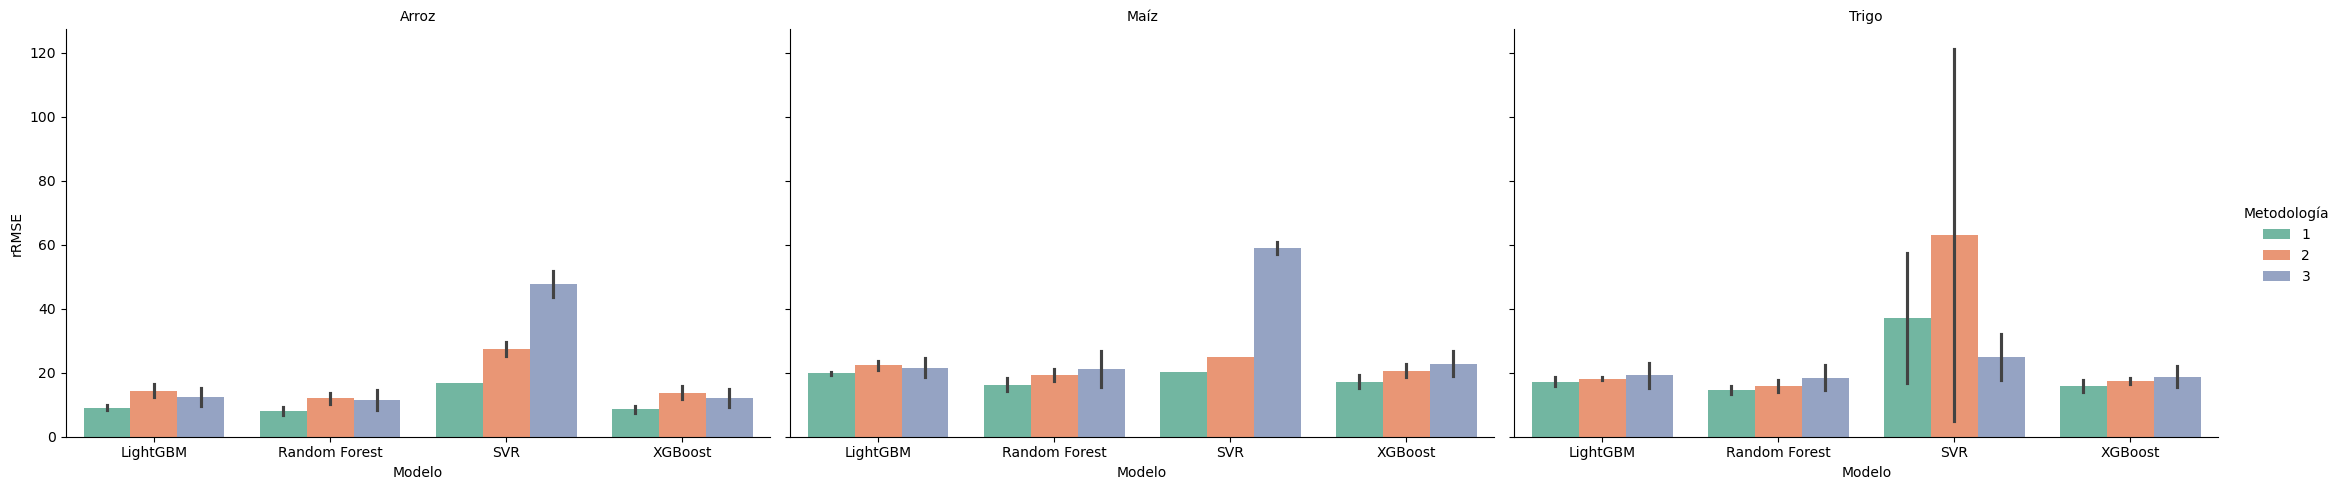

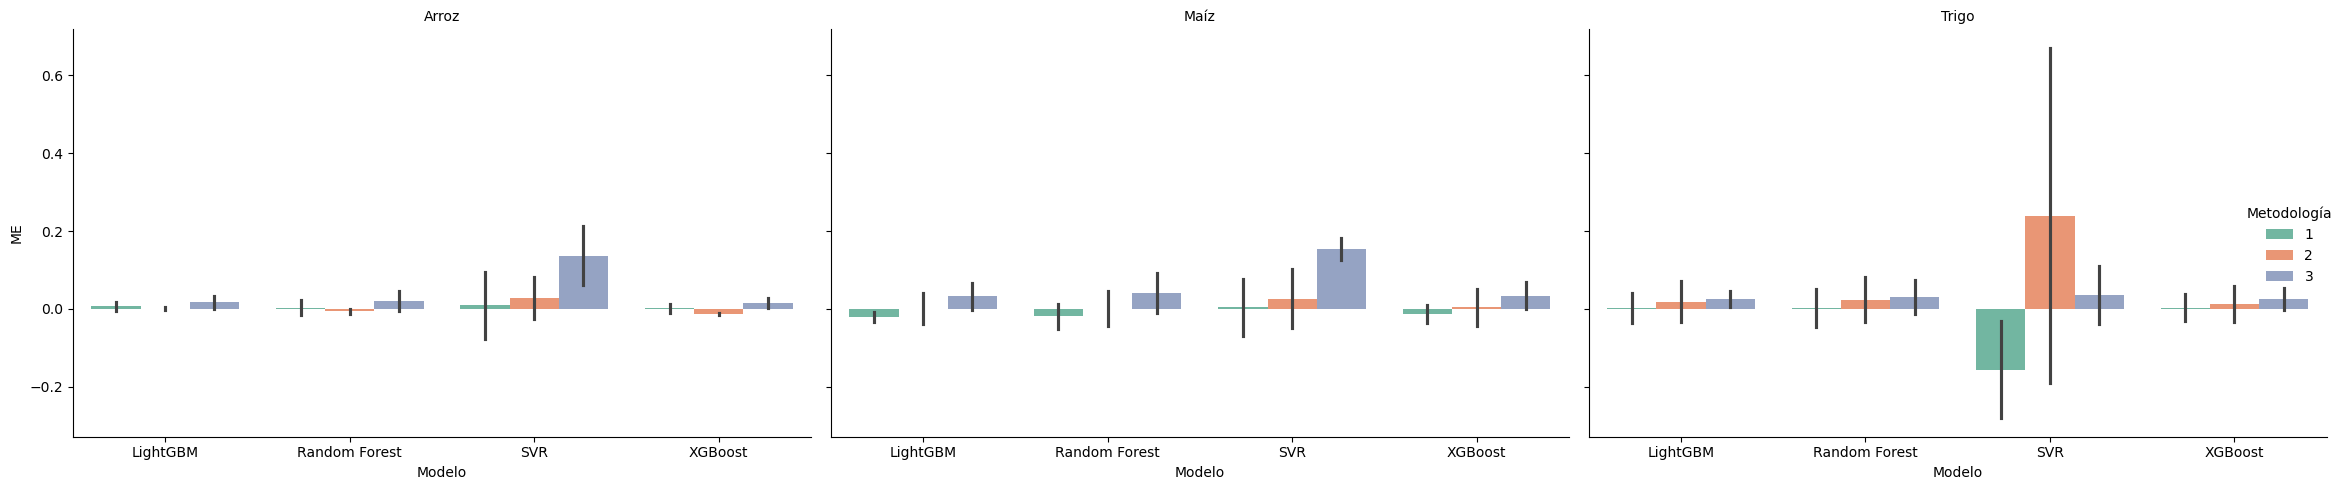

In [13]:
barplot_comparativo(df_total)

Aquí ya podemos observar algo más de información acerca del comportamiento de los modelos en cuanto al tipo de metodología y cultivo.

#### Boxplots globales

In [14]:
def boxplot_global(df_orig):
    """Mostrar un boxplot global de rRMSE y ME por modelo.
    
    Args:
        df (DataFrame): DataFrame con los resultados globales.
    """
    df = df_orig.copy()
    df = df.groupby("Modelo")[["rRMSE", "ME"]].mean().reset_index()

    orden_rrmse = df.sort_values(by="rRMSE")["Modelo"].tolist()
    orden_me = df.sort_values(by="ME")["Modelo"].tolist()

    fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

    # Paleta de colores
    modelos = df["Modelo"].unique().tolist()
    colores = sns.color_palette("husl", len(modelos))
    paleta = dict(zip(modelos, colores))

    # Boxplot de rRMSE
    sns.boxplot(data=df_orig, x="Modelo", y="rRMSE",
                ax=ax[0], palette=paleta, order=orden_rrmse)
    ax[0].set_title("Boxplot de rRMSE por Modelo")
    ax[0].set_ylabel("rRMSE (%)")
    ax[0].set_xticklabels(ax[0].get_xticklabels())

    # Boxplot de ME 
    sns.boxplot(data=df_orig, x="Modelo", y="ME",
                ax=ax[1], palette=paleta, order=orden_me)
    ax[1].set_title("Boxplot de ME por Modelo")
    ax[1].set_ylabel("ME")
    ax[1].set_xticklabels(ax[1].get_xticklabels())

    plt.suptitle("Disposición de resultados globales por Modelo", fontsize=16)
    plt.tight_layout()
    plt.show()

    print("Valores numéricos de rRMSE (%) y ME por Modelo:\n", df[["Modelo", "rRMSE", "ME"]].to_string(index=False))

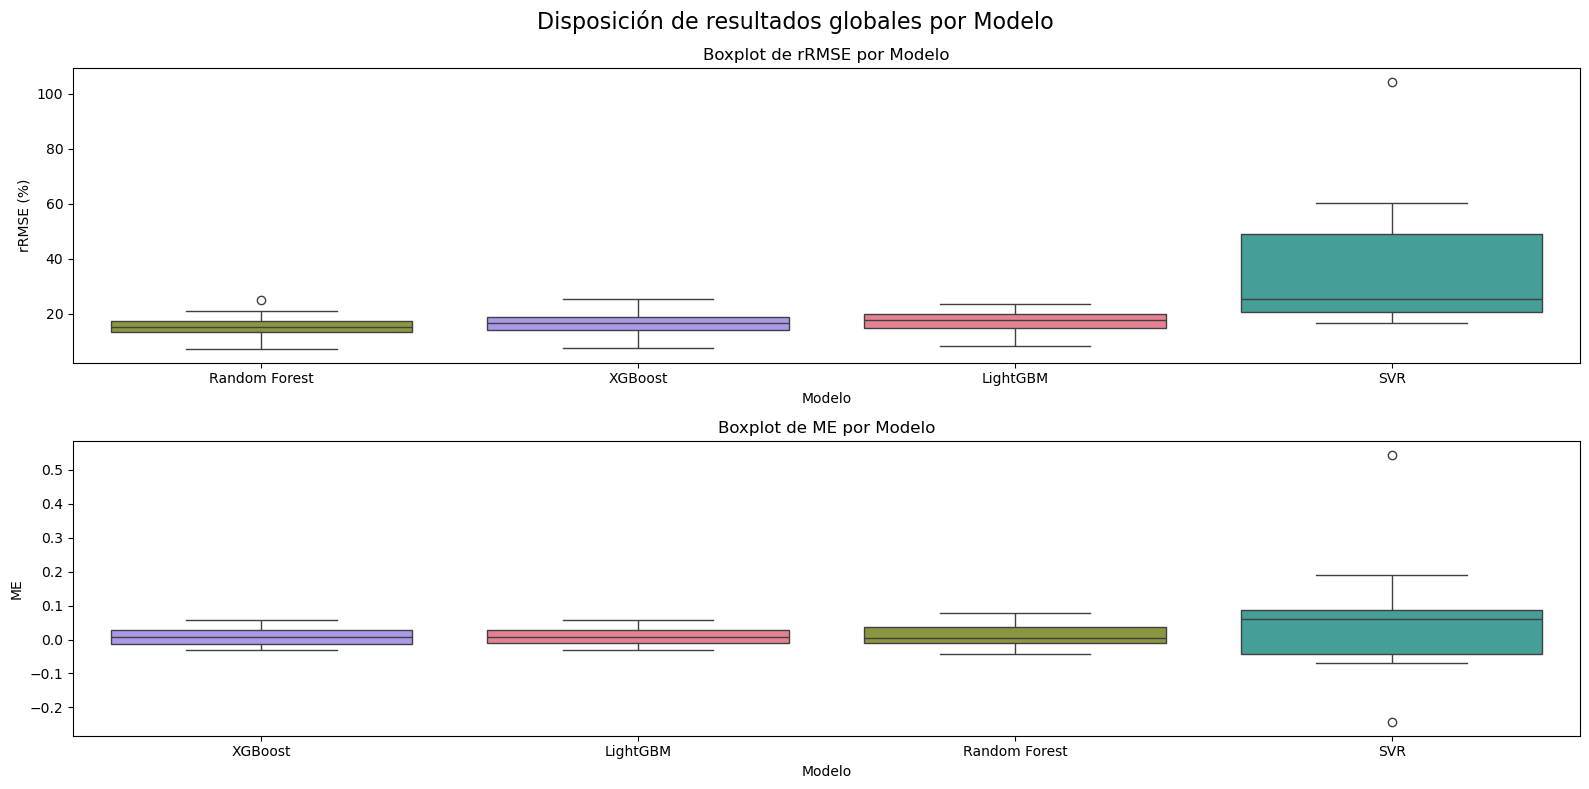

Valores numéricos de rRMSE (%) y ME por Modelo:
        Modelo     rRMSE       ME
     LightGBM 17.134362 0.009226
Random Forest 15.278199 0.010696
          SVR 35.717885 0.053214
      XGBoost 16.331330 0.008077


In [15]:
boxplot_global(df_total)

In [16]:
def boxplot_comparativo(df_orig):
    """Mostrar un barplot comparativo de rRMSE y ME por cultivo y metodología.
    
    Args:
        df_orig (DataFrame): DataFrame con los resultados por cultivo y metodología.
    """
    df = df_orig.copy()

    # rRMSE
    sns.catplot(data=df, x="Modelo", y="rRMSE", 
                col="Cultivo", kind="box", palette="Set2",
                ci="sd", height=5, aspect=1.5).set_titles("{col_name}")

    # ME
    sns.catplot(data=df, x="Modelo", y="ME",
                col="Cultivo", kind="box", palette="Set2",
                ci="sd", height=5, aspect=1.5).set_titles("{col_name}")

    plt.tight_layout()
    plt.show()

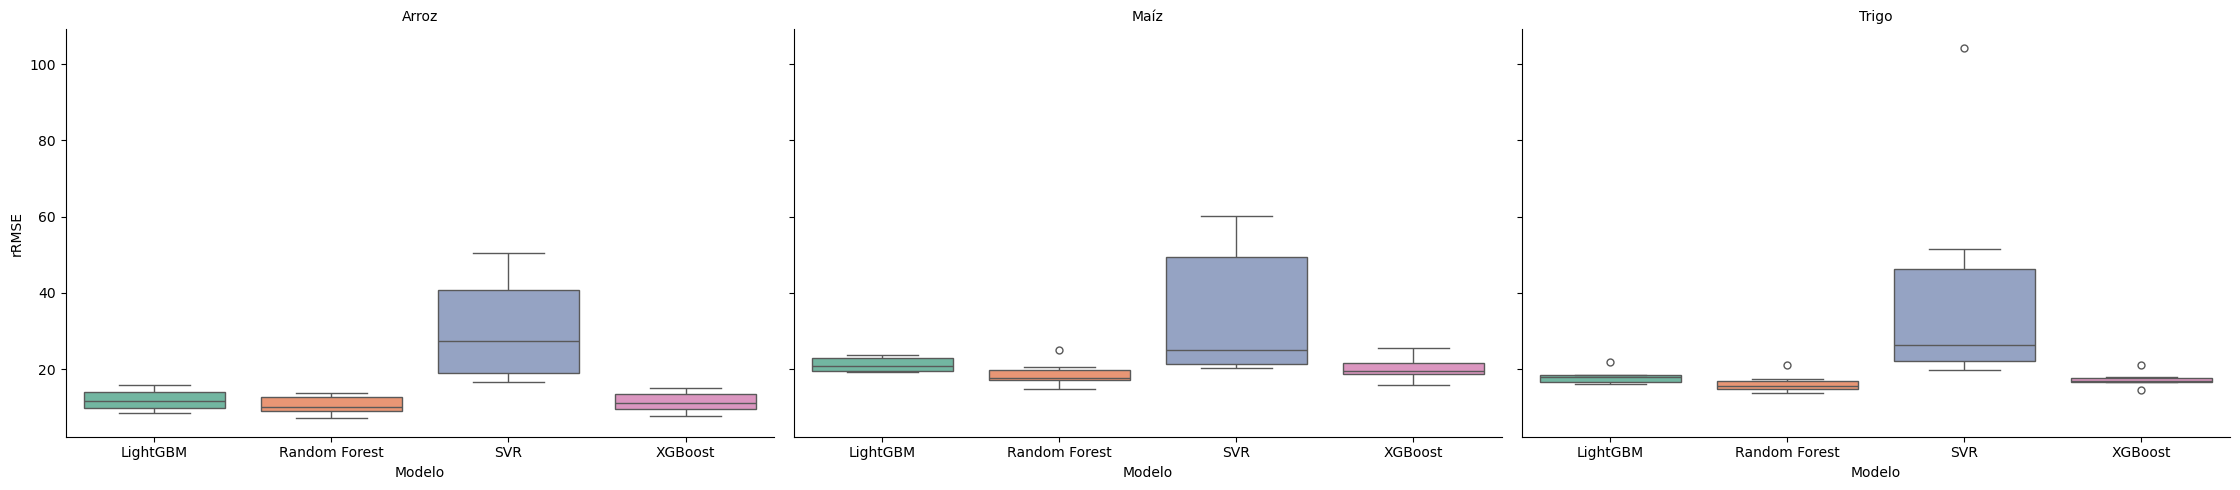

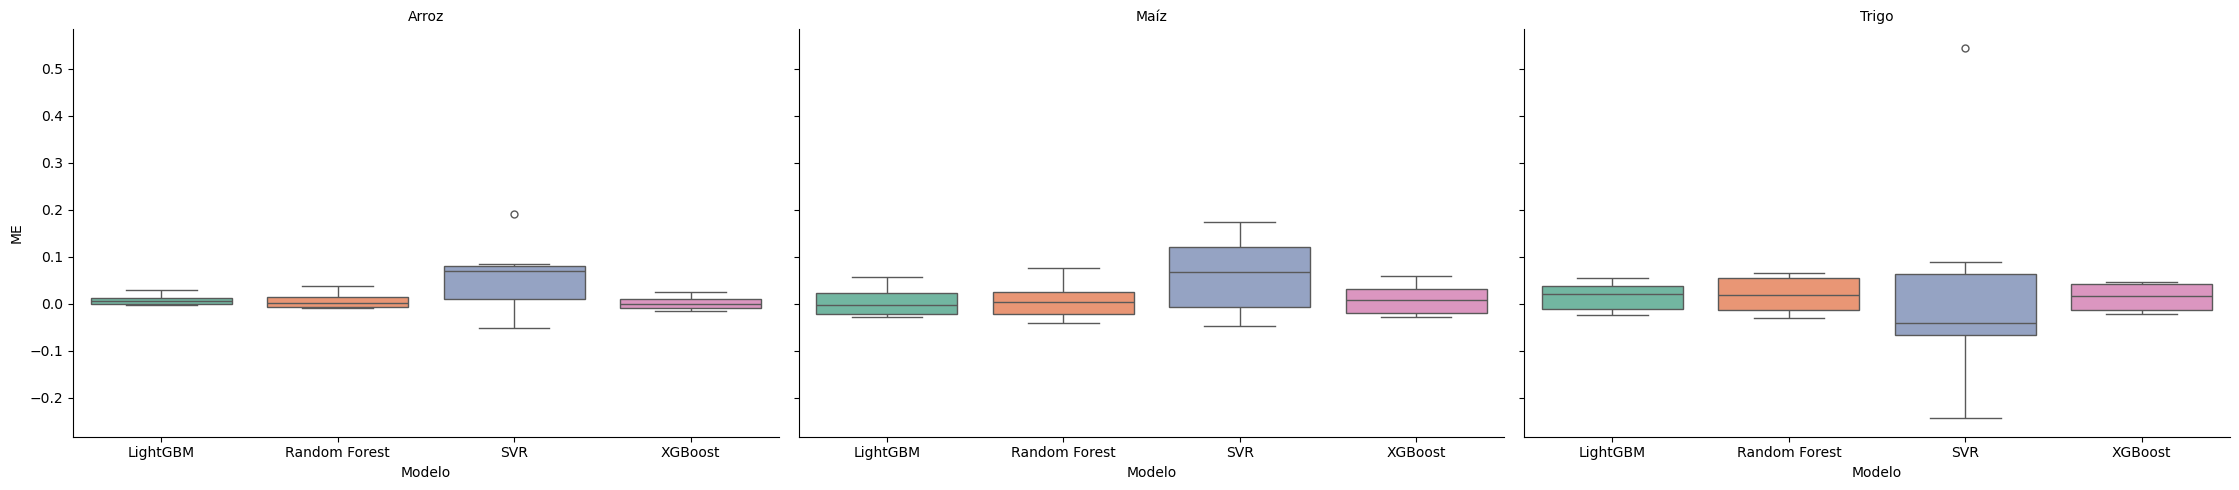

In [17]:
boxplot_comparativo(df_total)

#### Conclusiones

Con los resultados anteriores observamos que Random Forest es el mejor modelo en cuanto al error cuadrático relativo (rRMSE), aunque presenta outliers, seguido de XGBoost. En cuanto al error medio absoluto, vemos que el modelo con menor promedio es XGBoost, seguido de LightGBM y Random Forest.

Podríamos decir a simple vista que el modelo que mejor funciona en general es XGBoost, sin embargo, si tenemos en cuenta los valores numéricos vemos que los resultados de LightGBM no distan en gran medida de los de XGBoost y, además, observamos menor dispersión en los boxplots de LightGBM.

### Comparación de resultados por tipo de cultivo

#### Heatmap comparativo de rRMSE por modelo, estrategia y metodología, para cada cultivo.

In [18]:
def heatmap_comparacion(df_orig, metric):
    fig, axes = plt.subplots(1, 3, figsize=(30, 12))

    for i, cultivo in enumerate(df_orig['Cultivo'].unique()):
        df_cultivo = df_orig[df_orig['Cultivo'] == cultivo]
        pivot = df_cultivo.pivot_table(
            index='Modelo', columns=['Estrategia', 'Metodología'], values=metric)
        
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=axes[i])
        axes[i].set_title(f"Heatmap de {metric} - {cultivo}")
        axes[i].set_xlabel("Estrategia - Metodología")

    fig.suptitle(f"Heatmap de {metric} por Cultivo", fontsize=16)
    plt.tight_layout()
    plt.show()
        

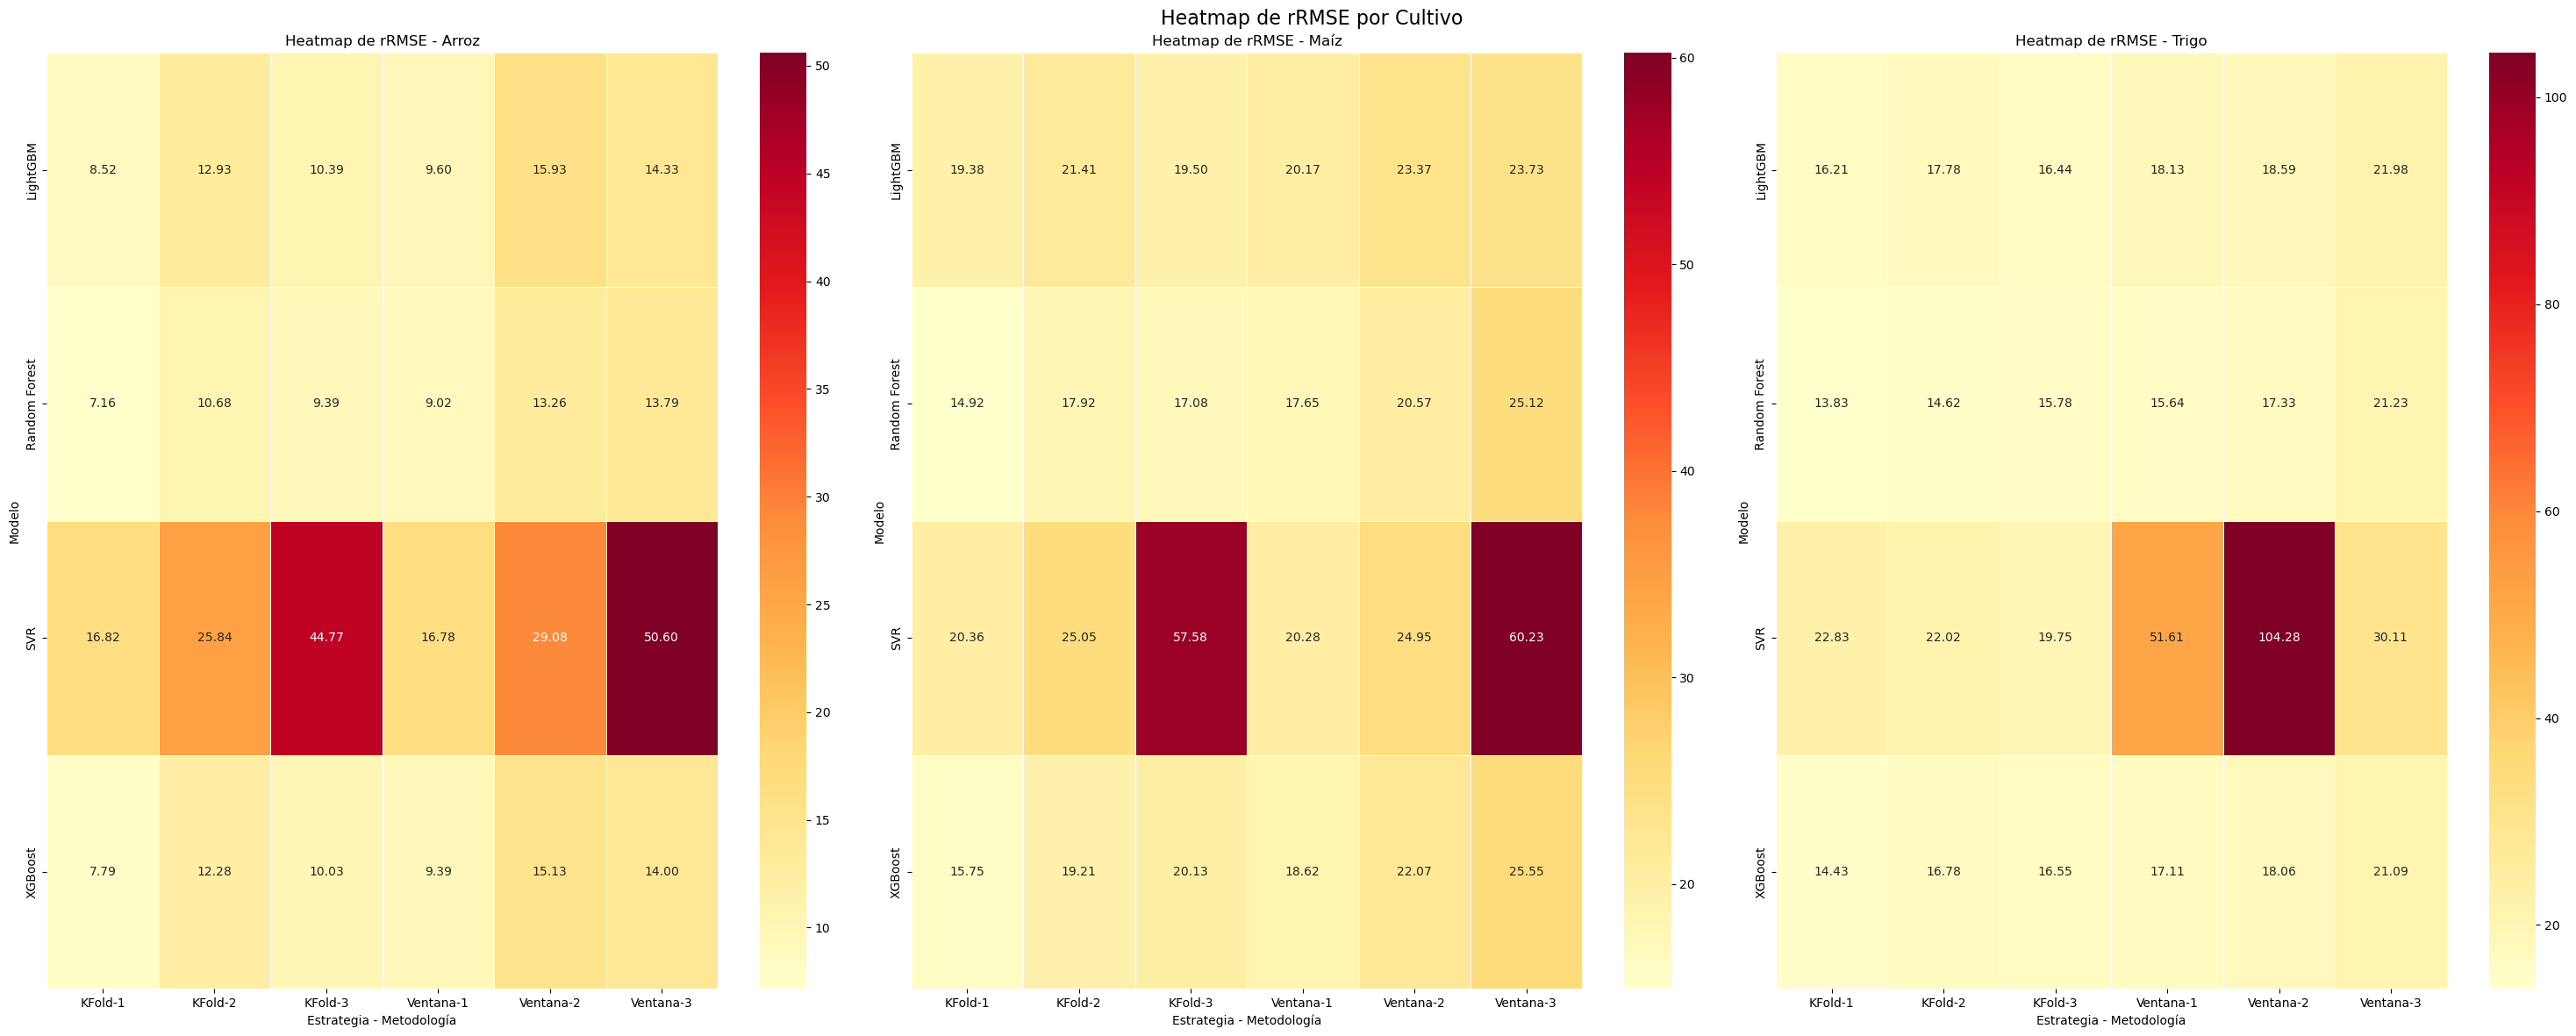

In [19]:
heatmap_comparacion(df_total, 'rRMSE')

##### Top 3 modelos por cultivo

· Arroz -> kfold_arroz_rf1 (7.16%), kfold_arroz_xgb1 (7.79%) & kfold_arroz_lgb1 (8.52%)

· Maiz -> kfold_maiz_rf1 (14.92%), kfold_maiz_xgb1 (15.75%) & kfold_maiz_rf3 (17.08%)

· Trigo -> kfold_trigo_rf1 (13.83%), kfold_trigo_xgb1 (14.43%) & kfold_trigo_rf2 (14.62%)

##### Mejores modelos por cultivo y tipo de modelo

· Arroz -> kfold_arroz_lgb1 (8.52%), kfold_arroz_rf1 (7.16%), vent_arroz_svr1 (16.78%) & kfold_arroz_xgb1 (7.79%)

· Maiz -> kfold_maiz_lgb1 (19.38%), kfold_maiz_rf1 (14.92%), vent_maiz_svr1 (20.28%), & kfold_maiz_xgb1 (15.75%)

· Trigo -> kfold_trigo_lgb1 (16.21%), kfold_trigo_rf1 (13.83%), kfold_trigo_svr3 (19.75%) & kfold_trigo_xgb1 (14.43%)


### Features importance

Vemos que en el Top 3 total por cultivo los modelos de Random Forest y XGBoost empleando K-Fold y agrupando por país son los dos que mejores resultados obtienen, respectivamente.

Para no reducir nuestro estudio en solo esos dos modelos, hemos seleccionado, para cada tipo de cultivo, la mejor configuración de los diferentes tipos de modelos empleados en el entrenamiento, es decir, el mejor de cada tipo. De esta manera no solo estudiaremos los modelos del Top 3, sino que podremos estudiar para cada tipo de cultivo en qué características se centran sus modelos por separado.

#### (Guardamos manualmente los mejores modelos en el archivo 'modelos.ipynb')

#### Cargamos modelos

In [20]:
# Arroz
training_kfold_arroz_lgb1 = joblib.load("./Mejores_modelos/training_kfold_arroz_lgb1.pkl")
training_kfold_arroz_rf1 = joblib.load("./Mejores_modelos/training_kfold_arroz_rf1.pkl")
training_kfold_arroz_xgb1 = joblib.load("./Mejores_modelos/training_kfold_arroz_xgb1.pkl")
training_vent_arroz_svr1 = joblib.load("./Mejores_modelos/training_vent_arroz_svr1.pkl")

# Maíz
training_kfold_maiz_lgb1 = joblib.load("./Mejores_modelos/training_kfold_maiz_lgb1.pkl")
training_kfold_maiz_rf1 = joblib.load("./Mejores_modelos/training_kfold_maiz_rf1.pkl")
training_kfold_maiz_xgb1 = joblib.load("./Mejores_modelos/training_kfold_maiz_xgb1.pkl")
training_vent_maiz_svr1 = joblib.load("./Mejores_modelos/training_vent_maiz_svr1.pkl")

# Trigo
training_kfold_trigo_lgb1 = joblib.load("./Mejores_modelos/training_kfold_trigo_lgb1.pkl")
training_kfold_trigo_rf1 = joblib.load("./Mejores_modelos/training_kfold_trigo_rf1.pkl")
training_kfold_trigo_xgb1 = joblib.load("./Mejores_modelos/training_kfold_trigo_xgb1.pkl")
training_kfold_trigo_svr3 = joblib.load("./Mejores_modelos/training_kfold_trigo_svr3.pkl")


#### Arroz

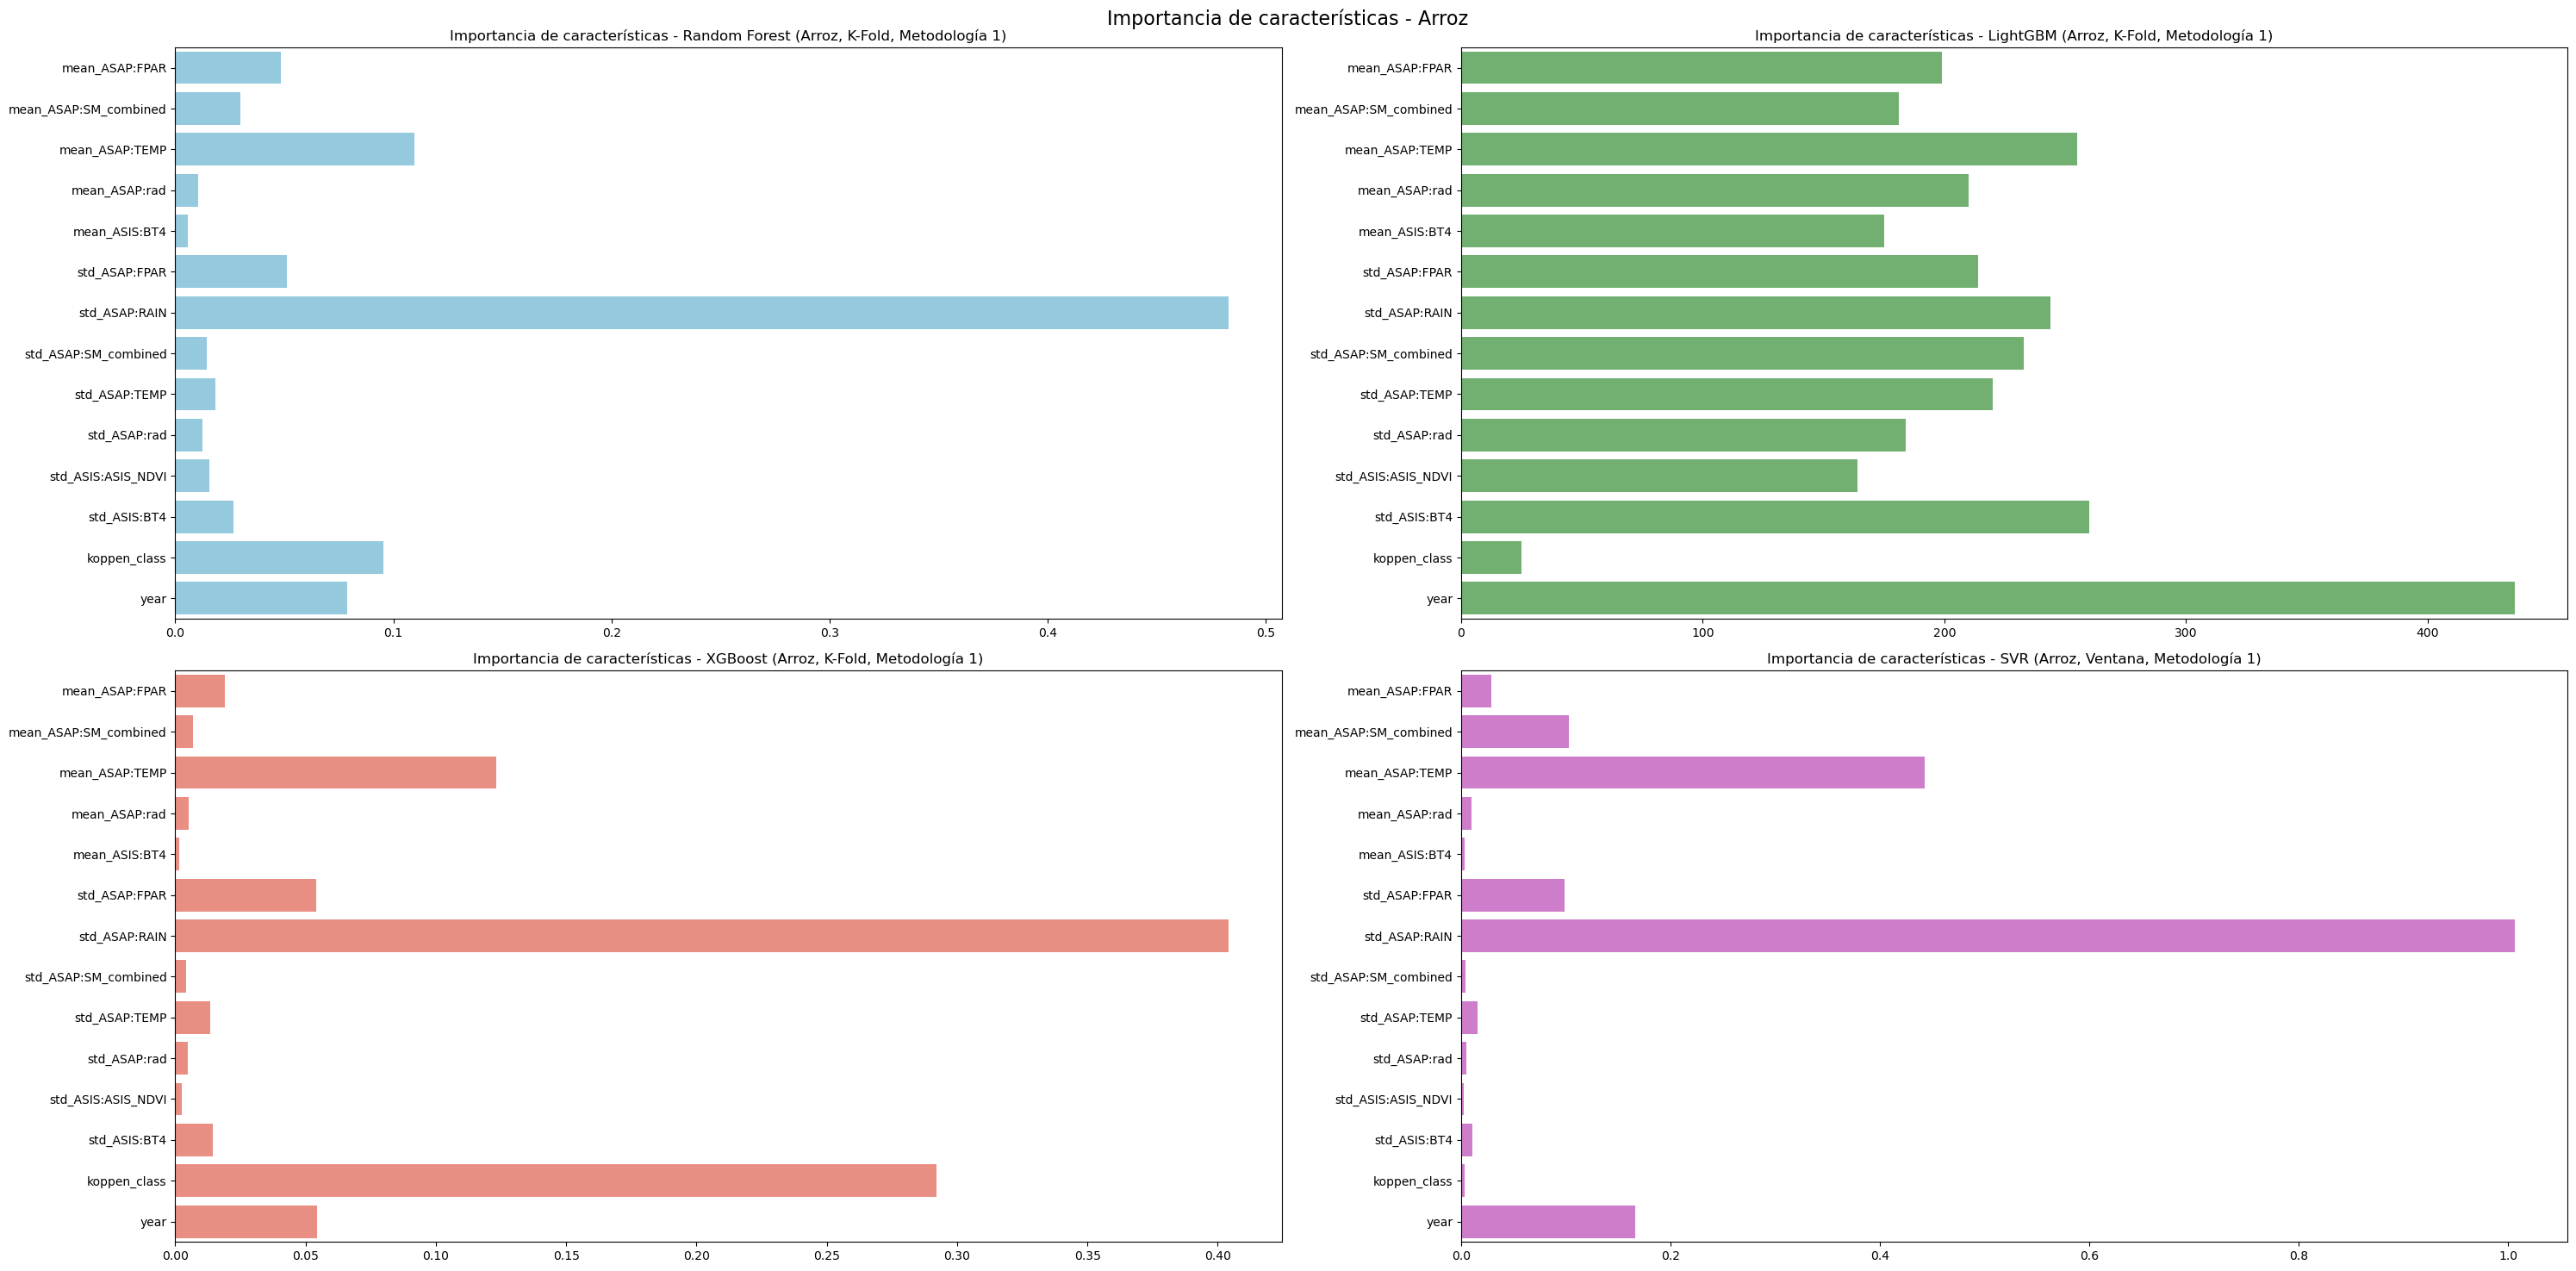

In [21]:
X_arroz = arroz[col_names_train_rice[:-1] + ["year"]]

fig, axes = plt.subplots(2, 2, figsize=(30, 15))
fig.suptitle("Importancia de características - Arroz", fontsize=16)

# Random Forest
model_arroz_rf = training_kfold_arroz_rf1
importances_rf = model_arroz_rf.feature_importances_
sns.barplot(x=importances_rf, y=list(X_arroz.columns), ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Importancia de características - Random Forest (Arroz, K-Fold, Metodología 1)")

# LightGBM
model_arroz_lgb = training_kfold_arroz_lgb1
importances_lgb = model_arroz_lgb.feature_importances_
sns.barplot(x=importances_lgb, y=list(X_arroz.columns), ax=axes[0, 1], color="#66bb66")
axes[0, 1].set_title("Importancia de características - LightGBM (Arroz, K-Fold, Metodología 1)")


# XGBoost
model_arroz_xgb = training_kfold_arroz_xgb1
importances_xgb = model_arroz_xgb.feature_importances_
sns.barplot(x=importances_xgb, y=list(X_arroz.columns), ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Importancia de características - XGBoost (Arroz, K-Fold, Metodología 1)")

# SVR - Al no tener un kernel lineal (poly, rbf o sigmoid), aplicamos Permutation Importance
model_arroz_svr = training_vent_arroz_svr1
result = permutation_importance(model_arroz_svr, X_arroz, arroz['yield'], n_repeats=30, random_state=42)
importances_svr = result.importances_mean
sns.barplot(x=importances_svr, y=list(X_arroz.columns), ax=axes[1, 1], color="orchid")
axes[1, 1].set_title("Importancia de características - SVR (Arroz, Ventana, Metodología 1)")

plt.tight_layout()
plt.show()

#### Maíz

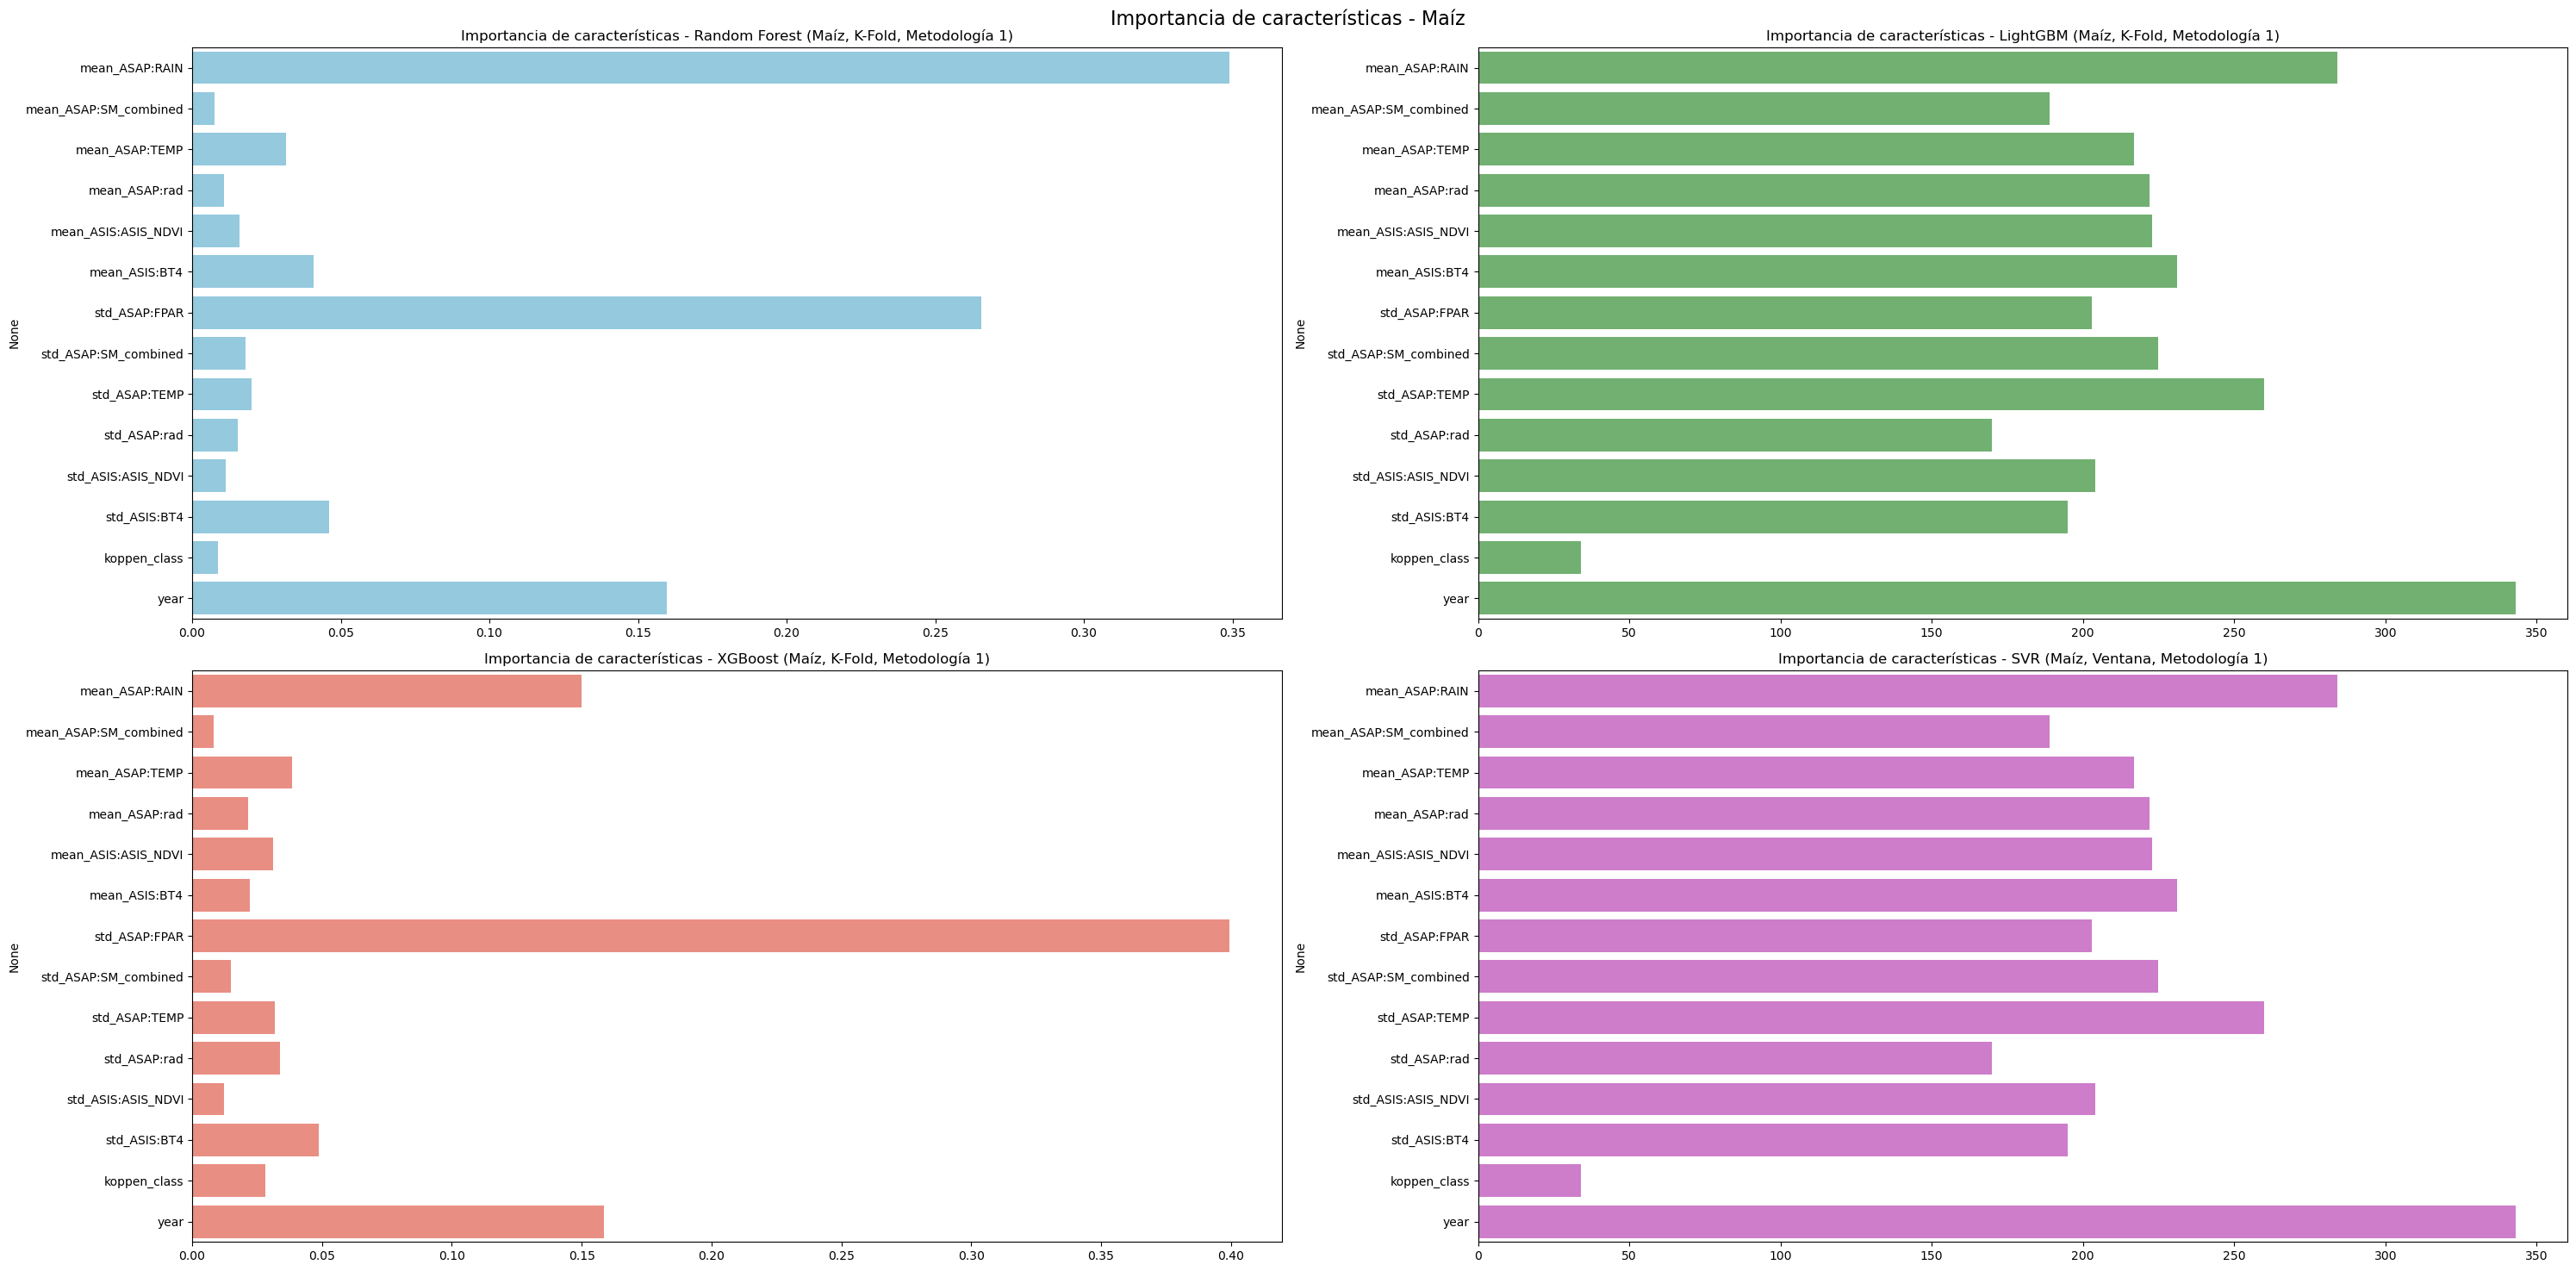

In [22]:
X_maiz = maiz[col_names_train_maize[:-1] + ["year"]]

fig, axes = plt.subplots(2, 2, figsize=(30, 15))
fig.suptitle("Importancia de características - Maíz", fontsize=16)

# Random Forest
model_maiz_rf = training_kfold_maiz_rf1
importances_rf = model_maiz_rf.feature_importances_
sns.barplot(x=importances_rf, y=X_maiz.columns, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Importancia de características - Random Forest (Maíz, K-Fold, Metodología 1)")

# LightGBM
model_maiz_lgb = training_kfold_maiz_lgb1
importances_lgb = model_maiz_lgb.feature_importances_
sns.barplot(x=importances_lgb, y=X_maiz.columns, ax=axes[0, 1], color="#66bb66")
axes[0, 1].set_title("Importancia de características - LightGBM (Maíz, K-Fold, Metodología 1)")

# XGBoost
model_maiz_xgb = training_kfold_maiz_xgb1
importances_xgb = model_maiz_xgb.feature_importances_
sns.barplot(x=importances_xgb, y=X_maiz.columns, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Importancia de características - XGBoost (Maíz, K-Fold, Metodología 1)")

# SVR - Kernel lineal, NO aplicamos Permutation Importance
model_maiz_svr = training_vent_maiz_svr1
importances_svr = model_maiz_svr.feature_importances_
sns.barplot(x=importances_svr, y=X_maiz.columns, ax=axes[1, 1], color="orchid")
axes[1, 1].set_title("Importancia de características - SVR (Maíz, Ventana, Metodología 1)")

plt.tight_layout()
plt.show()

#### Trigo

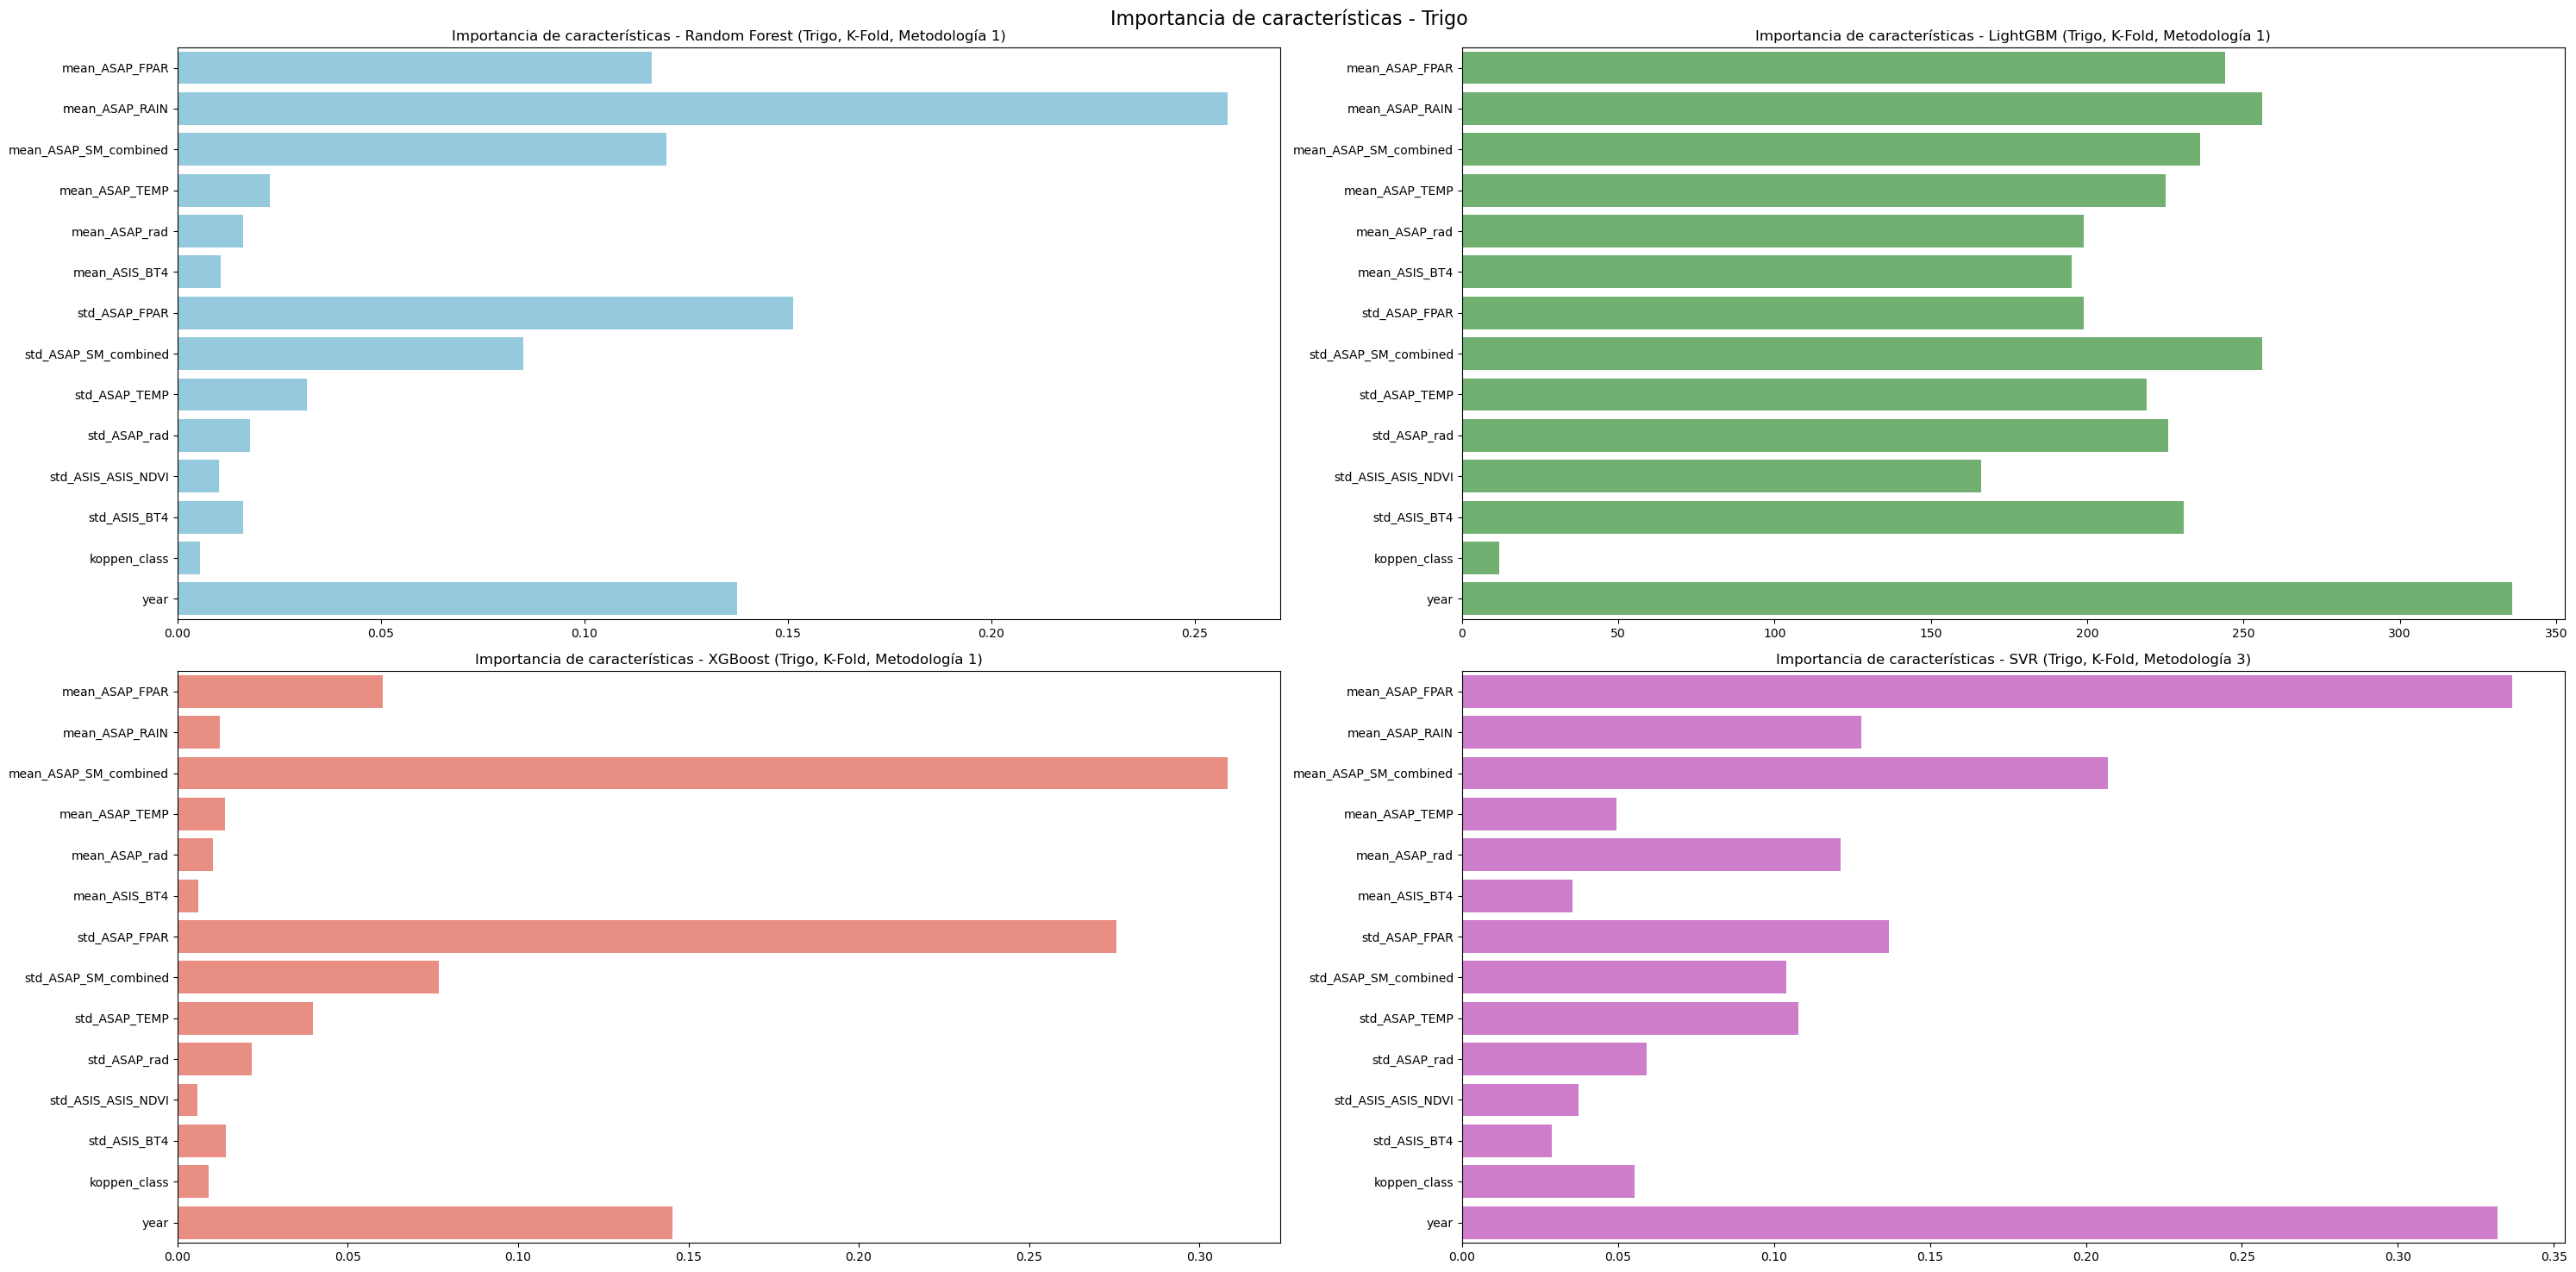

In [23]:
X_trigo = trigo[col_names_train_wheat[:-1] + ["year"]]
X_trigo.columns = X_trigo.columns.str.replace(':', '_', regex=False)

fig, axes = plt.subplots(2, 2, figsize=(30, 15))
fig.suptitle("Importancia de características - Trigo", fontsize=16)

# Random Forest
model_trigo_rf = training_kfold_trigo_rf1
importances_rf = model_trigo_rf.feature_importances_
sns.barplot(x=importances_rf, y=list(X_trigo.columns), ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Importancia de características - Random Forest (Trigo, K-Fold, Metodología 1)")

# LightGBM
model_trigo_lgb = training_kfold_trigo_lgb1
importances_lgb = model_trigo_lgb.feature_importances_
sns.barplot(x=importances_lgb, y=list(X_trigo.columns), ax=axes[0, 1], color="#66bb66")
axes[0, 1].set_title("Importancia de características - LightGBM (Trigo, K-Fold, Metodología 1)")

# XGBoost
model_trigo_xgb = training_kfold_trigo_xgb1
importances_xgb = model_trigo_xgb.feature_importances_
sns.barplot(x=importances_xgb, y=list(X_trigo.columns), ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Importancia de características - XGBoost (Trigo, K-Fold, Metodología 1)")

# SVR - Kernel no lineal (poly, rbf o sigmoid), aplicamos Permutation Importance
model_trigo_svr = training_kfold_trigo_svr3
result = permutation_importance(model_trigo_svr, X_trigo, trigo['yield'], n_repeats=30, random_state=42)
importances_svr = result.importances_mean
sns.barplot(x=importances_svr, y=list(X_trigo.columns), ax=axes[1, 1], color="orchid")
axes[1, 1].set_title("Importancia de características - SVR (Trigo, K-Fold, Metodología 3)")

plt.tight_layout()
plt.show()

### Análisis del mejor modelo por cultivo (Features importance)

Contrariamente a la idea que se tenía en un principio, el análisis de cada tipo de modelo aporta variedad al estudio a la vez que confusión sobre cuál actúa mejor. Seleccionaremos y estudiaremos ahora el modelo que consideramos mejores resultados obtiene.

In [24]:
def mejores_combinaciones(df_orig, metric):

    if metric == "rRMSE":
        return df_orig.loc[df_orig.groupby("Cultivo")[metric].idxmin()]
    elif metric == "ME":
        # Calcula el índice del valor más cercano a cero por cultivo
        idx = df_orig.groupby("Cultivo")[metric].apply(lambda x: (x.abs()).idxmin())
        return df_orig.loc[idx.values]
    else:
        raise ValueError("La métrica debe ser 'rRMSE' o 'ME'")

In [25]:
mejores_combinaciones(df_total, "rRMSE")

,Modelo,Metodología,Cultivo,Estrategia,rRMSE,ME
18,Random Forest,1,Arroz,KFold,7.160610,-0.010396
20,Random Forest,1,Maíz,KFold,14.915564,-0.041429
22,Random Forest,1,Trigo,KFold,13.833128,-0.031445


In [26]:
mejores_combinaciones(df_total, "ME")

,Modelo,Metodología,Cultivo,Estrategia,rRMSE,ME
25,Random Forest,2,Arroz,Ventana,13.263506,-0.001272
21,Random Forest,1,Maíz,Ventana,17.654592,0.003185
34,Random Forest,3,Trigo,KFold,15.781472,-0.001221


Seleccionamos los modelos con menor rRMSE ya que esta es una unidad que nos indica el error relativo porcentual, lo que significa que podemos usarla para evaluar conjuntos de datos heterogéneos. Teniendo esto en mente nos quedaremos con los modelos de Random Forest con K-Fold y metodología 1 (agrupación por país) para cada cultivo.

#### Arroz

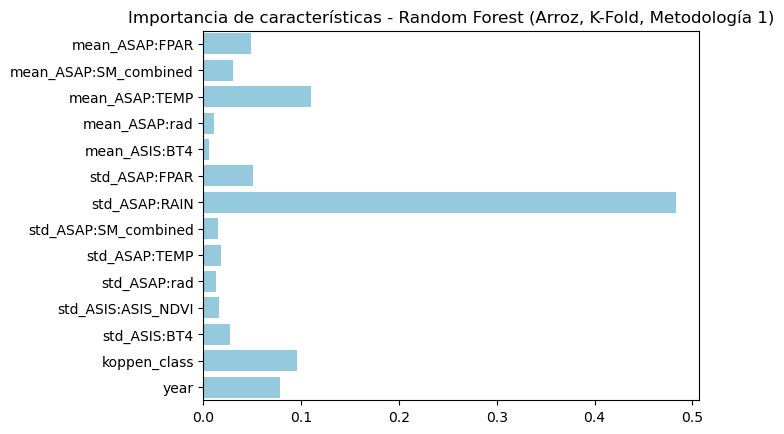

In [27]:
X_arroz = arroz[col_names_train_rice[:-1] + ["year"]]

model_arroz_rf = training_kfold_arroz_rf1
importances_rf = model_arroz_rf.feature_importances_
sns.barplot(x=importances_rf, y=list(X_arroz.columns), color="skyblue")
plt.title("Importancia de características - Random Forest (Arroz, K-Fold, Metodología 1)")
plt.show()

#### Maíz

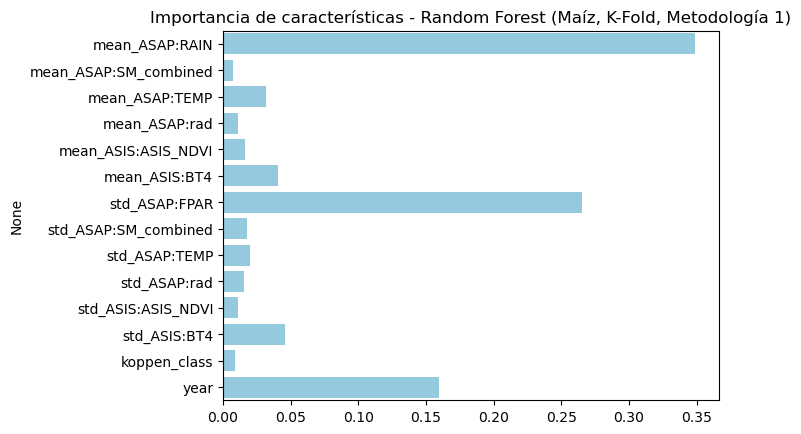

In [28]:
X_maiz = maiz[col_names_train_maize[:-1] + ["year"]]

model_maiz_rf = training_kfold_maiz_rf1
importances_rf = model_maiz_rf.feature_importances_
sns.barplot(x=importances_rf, y=X_maiz.columns, color="skyblue")
plt.title("Importancia de características - Random Forest (Maíz, K-Fold, Metodología 1)")
plt.show()

#### Trigo

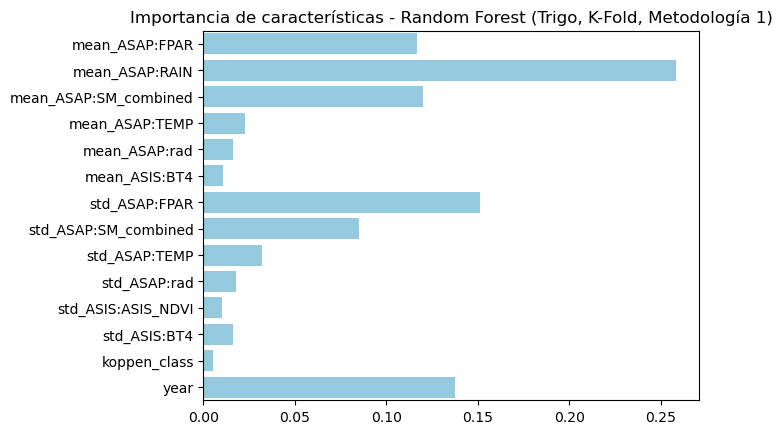

In [29]:
X_trigo = trigo[col_names_train_wheat[:-1] + ["year"]]

model_trigo_rf = training_kfold_trigo_rf1
importances_rf = model_trigo_rf.feature_importances_
sns.barplot(x=importances_rf, y=list(X_trigo.columns), color="skyblue")
plt.title("Importancia de características - Random Forest (Trigo, K-Fold, Metodología 1)")
plt.show()